In [2]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('./data/retailmax.csv')

In [4]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income,Spending Score
195,196,Female,35,120,79
34,35,Female,49,33,14
187,188,Male,28,101,68
188,189,Female,41,103,17
51,52,Male,33,42,60


In [5]:
features = df[['Age', 'Annual Income', 'Spending Score']]

In [9]:
features.head()

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [19]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [20]:
df["Cluster"] = clusters

In [21]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income,Spending Score,Cluster
80,81,Male,57,54,51,4
171,172,Male,28,87,75,2
189,190,Female,36,103,85,2
64,65,Male,63,48,51,4
25,26,Male,29,28,82,1


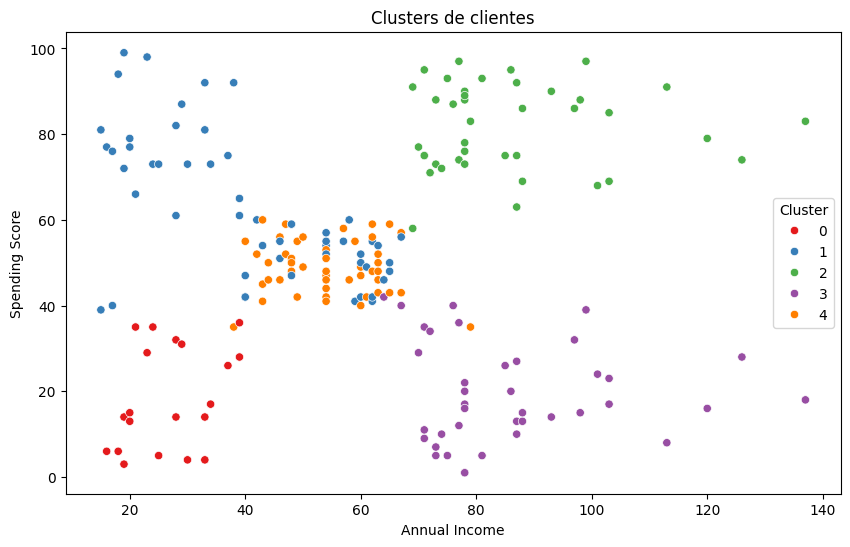

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income', y='Spending Score', hue='Cluster', palette='Set1')
plt.title('Clusters de clientes')
plt.show()

# Calculando el número ideal de clusters con el método elbow

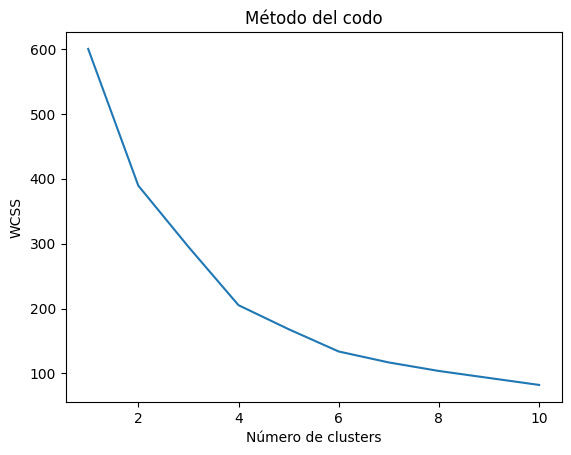

In [18]:
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

# Calcular el WCSS para diferentes números de clusters
wcss = calcular_wcss(scaled_features)

# Graficar el método del codo
plt.plot(range(1, 11), wcss)
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()